使用 Ultralytics 框架（如 YOLOv8）解决自己的目标检测问题可以分为以下几个步骤。

## 1. 准备数据集
目标检测需要标注好的图像数据，格式通常为 COCO JSON 或 YOLO 格式（每张图像对应一个 .txt 标注文件）。

以下是使用 LabelImg 标注目标检测数据的详细步骤指南，涵盖安装、标注流程、格式选择及注意事项：

### 1） 安装 LabelImg

In [6]:
!pip install labelImg

Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple
     -------------------------------------- 247.7/247.7 kB 2.6 MB/s eta 0:00:00
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Created wheel for labelImg: filename=labelImg-1.8.6-py2.py3-none-any.whl size=261578 sha256=ac76dbaf635d15210dd2472aae39783656201c13d5e236ccfd3cc0a5a11181be
  Stored in directory: c:\users\administrator\appdata\local\pip\cache\wheels\66\a6\31\ce4a035a531cef47b08165feb6a6b1ea6257ba3805b82754e9
Successfully built labelImg


安装完成后，命令行输入以下命令启动:

In [ ]:
!labelImg

启动界面如下：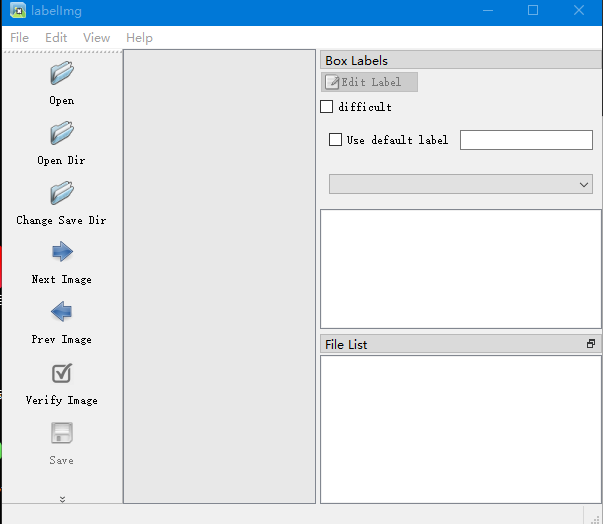

### 2） 标注前准备
+ 组织数据目录
<br>将待标注的图片放入一个文件夹（如 images/），建议按以下结构组织：
```python
dataset/
  ├── images/       # 存放所有待标注图片
  └── annotations/  # 存放生成的标注文件（自动创建）
```
+ 创建类别文件（可选）<br>
若需预定义类别（如 cat, dog），在 data/ 目录下创建 classes.txt，每行一个类别名。

### 3)  标注流程
+ 启动labelImg界面后，加载图片文件夹
    + 点击 Open Dir，选择 images/ 文件夹。
    + 点击 Change Save Dir，设置标注文件保存路径（如 annotations/）。
+ 创建标注框
    + 快捷键：按 W 进入绘制模式，鼠标拖拽绘制边界框。

    + 选择类别：从右侧类别列表中选择当前对象的类别（如 cat）。

    + 调整边界框：拖动框边缘或角点修正位置。

    + 保存标注：按 Ctrl + S 保存当前图片的标注文件。

+ 切换图片
    + 使用快捷键 D（下一张）或 A（上一张）快速切换图片。

### 4) 标注格式选择
LabelImg 支持两种主流格式，需在保存前设置：
+ Pascal VOC 格式（默认）
    + 生成 .xml 文件，包含图片尺寸、对象类别及边界框坐标（绝对像素值）。
+ YOLO 格式
    + 生成 .txt 文件，每行格式为 <class_id> <x_center_norm> <y_center_norm> <width_norm> <height_norm>（归一化到 0~1）。
    
<br>左侧菜单中有切换选项：
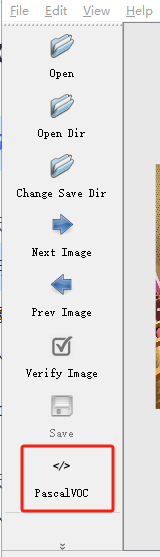
点击一下，切换为YOLO格式：
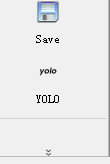

## 2. 安装 Ultralytics
确保环境已安装 Python（≥3.8）和 PyTorch（≥1.8），然后安装 Ultralytics：

In [2]:
!pip install ultralytics

Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple


In [5]:
# 测试安装是否成功
from ultralytics import YOLO

# 加载预训练模型
model = YOLO("yolov8n.pt")

# 测试推理
results = model.predict("YOLO_test1.jpg", save=True)  # 替换为你的测试图片路径


image 1/1 G:\TZ\BOOK\\YOLO_test1.jpg: 640x480 3 persons, 1 chair, 61.4ms
Speed: 2.7ms preprocess, 61.4ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 480)
Results saved to runs\detect\predict2


## 3. 训练模型
使用 YOLOv8 训练自定义模型：

In [ ]:
from ultralytics import YOLO

# 加载预训练模型
model = YOLO("yolov8n.pt")  

# 训练
results = model.train(
    data="data.yaml",
    epochs=100,
    imgsz=640,
    batch=16,
    device="0"  # 使用 GPU（如 "0,1" 多卡）
)